### 결측값 처리
- 타이타닉 데이터 준비


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [4]:
sns.set_theme(style="whitegrid", color_codes=True)

In [5]:
# 시본라이브러리 - 타이타닉 데이터 준비

df = sns.load_dataset("titanic")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [6]:
# 데이터를 소수점 두 번째 자리까지 출력
# 전체 데이터프레임의 포맷을 정돈할 때

pd.options.display.float_format = '{:.2f}'.format
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.00,1,0,7.25,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.00,1,0,71.28,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.00,0,0,7.92,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.00,1,0,53.10,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.00,0,0,8.05,S,Third,man,True,NaN,Southampton,no,True


## 결측치 처리
- 타이타닉 데이터
- 나이  결측값 -> 티켓등급별 평균값으로 변환

In [ ]:
# df.age 컬럼의 데이터의 수

df.age.notnull().sum()


In [ ]:
# df.age 컬럼의  결측치 데이터의 수
# 전체 891 - 널아닌값 714 = 177 결측치

df.age.isnull().sum()


In [ ]:
#  결측치 값의 합을 데이터의 개수로 나눠 비율로 출력

df.isnull().sum() / len(df) * 100

In [ ]:
# 성별 나이의 평균
# 통계값을 계산시 결측치 값을 기본적으로 배제됨!

df[df["age"].notnull()].groupby( ["sex"])["age"].mean()

#df.groupby( ["sex"])["age"].mean()    # 위와 결과가 같다


In [ ]:
# 티켓 클래스(pclass) 별 나이의 평균

df.groupby( ["pclass"])["age"].mean()


In [ ]:
# age 컬럼이 NaN인 pclass와 age 값
# index 5 : pclass 3 평균 => 25.14 // index 17 : pclass 2 평균=> 29.88

df.loc[df['age'].isnull(),['pclass', 'age']]

In [ ]:
# age 컬럼에서 NaN인 값을 위에서 계산한 pclass별 평균값으로 채웁니다.

df['age'] = df["age"].fillna(  df.groupby("pclass")["age"].transform("mean")  )

# 5행~ 20행 까지 출력
# index 5, 17 확인할 것 -> 나이가 등급별 평균으로 변환되어 있음
df[5:20]

## 결측치 처리
- 타이타닉 데이터
- 승선항구  결측값 -> 최빈값으로 변환

In [ ]:
# embarked : 승선항구
# 승선항구가 널인 값의 갯수

df['embarked'].isna().sum()

In [ ]:
# 승선항구가 널인 위치(인덱스) 출력

df[df['embarked'].isna()].index

In [ ]:
# 승선항구의 종류별 카운트

df['embarked'].value_counts()

In [ ]:
# 승선항구의 최빈값 출력

df['embarked'].mode()

,embarked
0,S


In [ ]:
# 승선항구가 널인 값을 특정값으로 수정
# df.loc[행, 열]

df.loc[61,"embarked"] = "S"
df.loc[829,"embarked"] = "S"

# 위 코드를 한번에
df.loc[ [61,829],'embarked' ] ='S'

# 변경내용 확인
df.loc[[61, 829]]

In [ ]:
df = sns.load_dataset("titanic")

x = df['embarked'].mode()
x

,embarked
0,S


In [ ]:
df = sns.load_dataset("titanic")

x = df['embarked'].mode()[0]
x

In [ ]:
# 승선항구의 널값을 최빈값으로 변경

df = sns.load_dataset("titanic")

x = df['embarked'].mode()[0]
df['embarked']=df['embarked'].fillna( x )

# 61, 829 인덱스의 정보 확인 -> embarked 컬럼값 확인
df.loc[[61, 829]]

### 범주형 데이터 처리
- 타이타닉 데이터
- 원핫인코딩

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [ ]:
# 시본라이브러리 - 타이타닉 데이터 준비

df = sns.load_dataset("titanic")

df.info()

In [7]:
# 데이터 타입 변형 :
# 숫자 데이터, 범주형 데이터 구분 => 즉, 계산할 데이터 / 카테고리 데이터 구분

# 문자컬럼 / 숫자컬럼 구분
object_columns  = ["pclass", "sex", "embarked"]
numeric_columns = ["age", "sibsp", "parch", "fare"]

# 데이터 타입 변경
for col_name in object_columns:
    df[col_name] = df[col_name].astype(object)

for col_name in numeric_columns:
    df[col_name] = df[col_name].astype(float)

# parch, sibsp 컬럼은 정수형으로 변경
df["parch"] = df["parch"].astype(int)
df["sibsp"] = df["sibsp"].astype(int)


In [ ]:
df.info()

In [ ]:
# 특정 컬럼 안의 유일값 확인

df['sex'].unique()

In [ ]:
# 범주형 데이터 중 데이터 유형이 작은 3개의 데이터
# sex : male, female
# pclass : 1, 2, 3
# embarked : 'S', 'C', 'Q' :


In [11]:
# merge_and_get 함수
# index 가 True 이면 인덱스로 결함 / index 가 False 이면 열 이름으로 결합

def merge_and_get(ldf, rdf, on, index=None):
    if index is True:
        return pd.merge(ldf,rdf, left_index=True, right_index=True)   # 모두 True 임
    else:
        return pd.merge(ldf,rdf, on=on)

In [ ]:
 # get_dummies 함수로 원핫인코딩

pd.get_dummies(df["sex"], prefix="sex").astype(int)

In [13]:
# 원본 + 원핫인코딩 => on_hot_df 생성

df = df[ ['survived','pclass','sex','embarked']]

one_hot_df = merge_and_get( df, pd.get_dummies(df["sex"], prefix="sex").astype(int), on=None, index=True)

one_hot_df = merge_and_get( one_hot_df, pd.get_dummies(  df["pclass"], prefix="pclass").astype(int), on=None, index=True)

one_hot_df = merge_and_get( one_hot_df, pd.get_dummies(  df["embarked"], prefix="embarked").astype(int), on=None, index=True)


In [ ]:
one_hot_df

# 데이터 시각화
- 성별 / 티켓등급 / 승선항구 가 생존에 영향을 미쳤나?

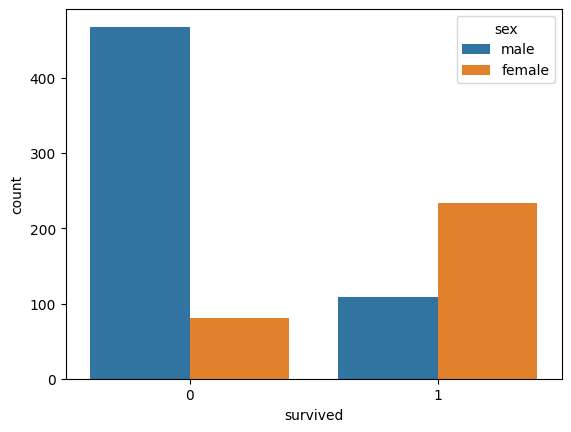

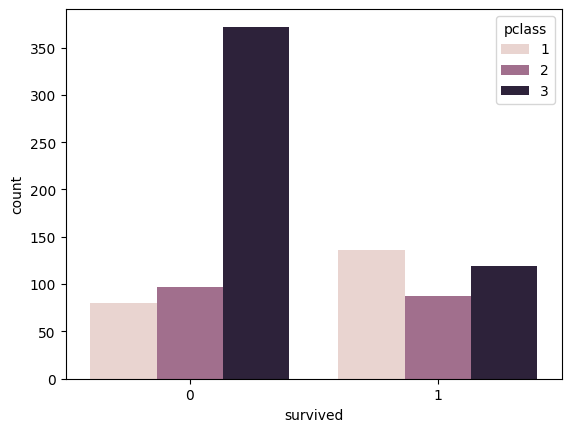

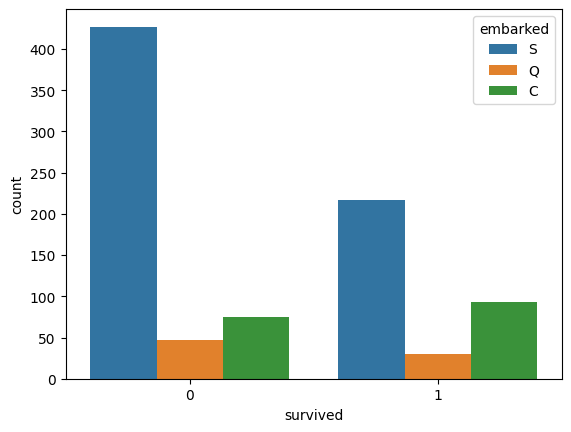

In [15]:
temp_columns = ["sex", "pclass", "embarked"]
y_true = df["survived"]

for col_name in temp_columns:
    temp_df = pd.merge( one_hot_df[col_name], y_true, left_index=True, right_index=True)
    sns.countplot(x="survived", hue=col_name, data=temp_df)
    plt.show()

In [ ]:
# 3개 컬럼 + 하나의 컬럼 => temp_df 생성

temp_columns = ["sex", "pclass", "embarked"]
y_true = df["survived"]

temp_df = pd.merge(one_hot_df[temp_columns], y_true, left_index=True, right_index=True)
temp_df

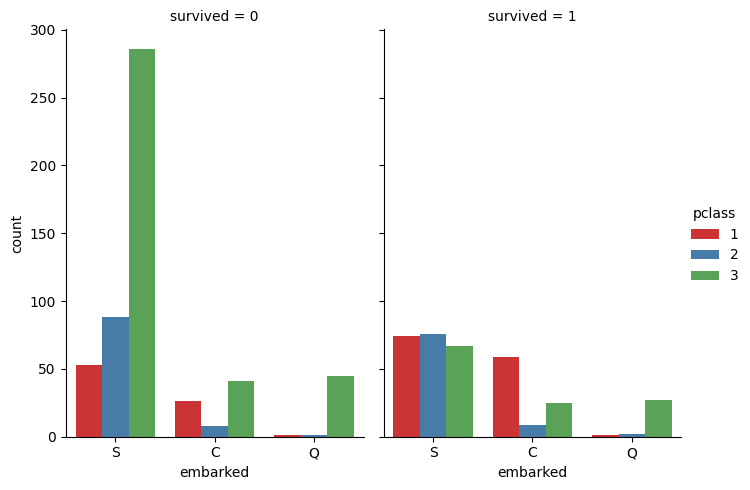

In [18]:
# catplot : Seaborn 라이브러리에서 범주형 데이터를 시각화할 때 사용하는 다목적 시각화 함수
# catplot : 캣플롭 , cat은 categorical의 줄임말

temp_columns = ["sex", "pclass", "embarked"]
y_true = df["survived"]

temp_df = pd.merge(one_hot_df[temp_columns], y_true, left_index=True, right_index=True)

sns.catplot(    x="embarked",
                hue="pclass",
                col="survived",  # 열 방향으로 생존 여부(0, 1) 별 서브플롯 분리
                data=temp_df,
                kind="count",
                height=5,        # 각 그래프의 높이
                aspect=0.7,      # 너비 비율 (그래프 폭 조절)
                palette='Set1')  # 범주별 다른 색상 지정

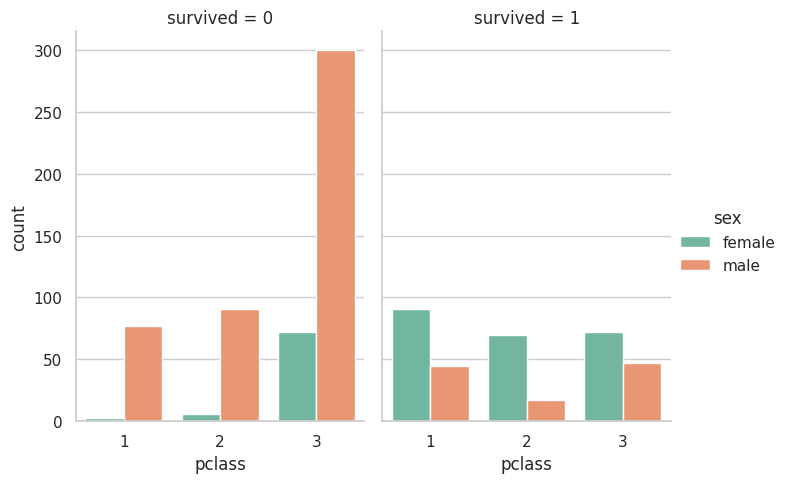

In [ ]:
sns.catplot(    x="pclass",
                hue="sex",
                col="survived",  # 열 방향으로 생존 여부(0, 1) 별 서브플롯 분리
                data=temp_df,
                kind="count",
                height=5,        # 각 그래프의 높이
                aspect=0.7,      # 너비 비율 (그래프 폭 조절)
                palette='Set2')  # 범주별 다른 색상 지정
plt.show()

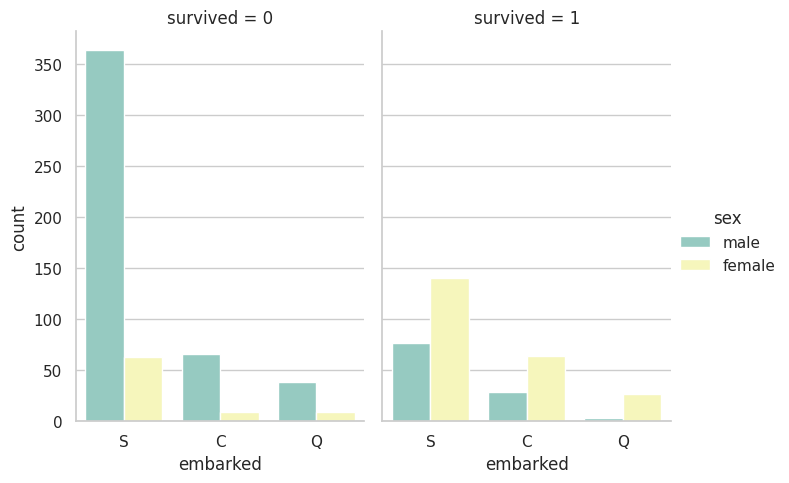

In [ ]:
sns.catplot(    x="embarked",
                hue="sex",
                col="survived",  # 열 방향으로 생존 여부(0, 1) 별 서브플롯 분리
                data=temp_df,
                kind="count",
                height=5,        # 각 그래프의 높이
                aspect=0.7,      # 너비 비율 (그래프 폭 조절)
                palette='Set3')  # 범주별 다른 색상 지정
plt.show()